# 05 Market Basket Analysis

This notebook analyzes which products are commonly purchased together in the same invoice.

The goal is to identify:
- Product combinations that frequently appear together
- Potential bundle opportunities
- Potential cross-selling opportunities

This analysis uses invoice-level product combinations. Non-product rows such as postage, fees, and manual adjustments are excluded so the basket analysis focuses only on real products.

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/online_retail_cleaned.csv",
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "CustomerID": "Int64"
    },
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,HasCustomerID,ProductDescription,TotalPrice,IsHighValueOutlier,IsNonProduct
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,True,WHITE HANGING HEART T-LIGHT HOLDER,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,WHITE METAL LANTERN,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,True,CREAM CUPID HEARTS COAT HANGER,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,KNITTED UNION FLAG HOT WATER BOTTLE,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,RED WOOLLY HOTTIE WHITE HEART.,20.34,False,False


In [3]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (524878, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           524878 non-null  string        
 1   StockCode           524878 non-null  string        
 2   Description         524878 non-null  object        
 3   Quantity            524878 non-null  int64         
 4   InvoiceDate         524878 non-null  datetime64[ns]
 5   UnitPrice           524878 non-null  float64       
 6   CustomerID          392692 non-null  Int64         
 7   Country             524878 non-null  object        
 8   IsCancelled         524878 non-null  bool          
 9   HasCustomerID       524878 non-null  bool          
 10  ProductDescription  524878 non-null  object        
 11  TotalPrice          524878 non-null  float64       
 12  IsHighValueOutlier  524878 non-null  bool          
 13  I

In [4]:
basket_df = df[df["IsNonProduct"] == False].copy()

print("Original dataset shape:", df.shape)
print("Basket dataset shape:", basket_df.shape)
print("Non-product rows remaining:", basket_df["IsNonProduct"].sum())

Original dataset shape: (524878, 14)
Basket dataset shape: (522724, 14)
Non-product rows remaining: 0


In [5]:
invoice_product_counts = basket_df.groupby("InvoiceNo")["ProductDescription"].nunique()

invoice_product_counts.describe()

count    19787.000000
mean        26.143124
std         46.984301
min          1.000000
25%          6.000000
50%         15.000000
75%         29.000000
max       1107.000000
Name: ProductDescription, dtype: float64

In [6]:
multi_product_invoices = invoice_product_counts[invoice_product_counts >= 2].index

basket_df = basket_df[basket_df["InvoiceNo"].isin(multi_product_invoices)].copy()

print("Basket dataset shape after keeping multi-product invoices:", basket_df.shape)
print("Number of invoices used for basket analysis:", basket_df["InvoiceNo"].nunique())

Basket dataset shape after keeping multi-product invoices: (521205, 14)
Number of invoices used for basket analysis: 18275


## Prepare Product Baskets

For market basket analysis, each invoice is treated as one basket.

A basket contains the unique products purchased together in the same invoice.

To keep the analysis focused and efficient, this notebook first analyzes co-purchases among the top 100 most frequently purchased products.

In [7]:
top_products = (
    basket_df["ProductDescription"]
    .value_counts()
    .head(100)
    .index
)

top_products[:10]

Index(['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT',
       'REGENCY CAKESTAND 3 TIER', 'PARTY BUNTING', 'LUNCH BAG RED RETROSPOT',
       'ASSORTED COLOUR BIRD ORNAMENT', 'POPCORN HOLDER',
       'SET OF 3 CAKE TINS PANTRY DESIGN ', 'PACK OF 72 RETROSPOT CAKE CASES',
       'LUNCH BAG SUKI DESIGN '],
      dtype='object', name='ProductDescription')

In [8]:
basket_top = basket_df[basket_df["ProductDescription"].isin(top_products)].copy()

print("Basket data shape before top product filter:", basket_df.shape)
print("Basket data shape after top product filter:", basket_top.shape)
print("Unique products included:", basket_top["ProductDescription"].nunique())
print("Invoices included:", basket_top["InvoiceNo"].nunique())

Basket data shape before top product filter: (521205, 14)
Basket data shape after top product filter: (98247, 14)
Unique products included: 100
Invoices included: 15563


In [9]:
invoice_baskets = (
    basket_top.groupby("InvoiceNo")["ProductDescription"]
    .apply(lambda x: sorted(set(x)))
)

invoice_baskets.head()

InvoiceNo
536365                 [WHITE HANGING HEART T-LIGHT HOLDER]
536367    [ASSORTED COLOUR BIRD ORNAMENT, HOME BUILDING ...
536368                           [JAM MAKING SET WITH JARS]
536370    [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...
536373    [WHITE HANGING HEART T-LIGHT HOLDER, WOODEN FR...
Name: ProductDescription, dtype: object

In [10]:
basket_sizes = invoice_baskets.apply(len)

basket_sizes.describe()

count    15563.000000
mean         6.244297
std          7.142082
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         93.000000
Name: ProductDescription, dtype: float64

In [11]:
invoice_baskets = invoice_baskets[invoice_baskets.apply(len) >= 2]

print("Number of baskets with at least 2 top products:", len(invoice_baskets))

Number of baskets with at least 2 top products: 12922


In [12]:
from collections import Counter

pair_counter = Counter()

for basket in invoice_baskets:
    for pair in combinations(basket, 2):
        pair_counter[pair] += 1

len(pair_counter)

4950

In [13]:
product_pairs = pd.DataFrame(
    pair_counter.items(),
    columns=["ProductPair", "PairCount"]
)

product_pairs[["ProductA", "ProductB"]] = pd.DataFrame(
    product_pairs["ProductPair"].tolist(),
    index=product_pairs.index
)

product_pairs = product_pairs[[
    "ProductA",
    "ProductB",
    "PairCount"
]].sort_values(
    by="PairCount",
    ascending=False
).reset_index(drop=True)

product_pairs.head(20)

,ProductA,ProductB,PairCount
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,825
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767
2,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,724
3,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY,680
4,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN,655
5,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,641
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,640
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632
8,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,606
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598


## Association Metrics

Product pair counts show which products appear together most often.

However, popular products may appear in many pairs simply because they are purchased often. To better measure the strength of product relationships, this analysis calculates:

- Support: percentage of baskets containing both products
- Confidence: probability that Product B appears when Product A appears
- Lift: how much stronger the relationship is compared to random chance

A lift value greater than 1 suggests that two products are purchased together more often than expected.

In [14]:
product_counter = Counter()

for basket in invoice_baskets:
    for product in basket:
        product_counter[product] += 1

product_counts = pd.DataFrame(
    product_counter.items(),
    columns=["Product", "ProductBasketCount"]
).sort_values(
    by="ProductBasketCount",
    ascending=False
)

product_counts.head(10)

,Product,ProductBasketCount
9,WHITE HANGING HEART T-LIGHT HOLDER,2142
34,JUMBO BAG RED RETROSPOT,2054
60,REGENCY CAKESTAND 3 TIER,1851
78,PARTY BUNTING,1580
17,LUNCH BAG RED RETROSPOT,1555
0,ASSORTED COLOUR BIRD ORNAMENT,1358
81,SET OF 3 CAKE TINS PANTRY DESIGN,1340
36,POPCORN HOLDER,1324
19,PACK OF 72 RETROSPOT CAKE CASES,1293
48,LUNCH BAG SUKI DESIGN,1279


In [15]:
total_baskets = len(invoice_baskets)

product_pairs["ProductACount"] = product_pairs["ProductA"].map(product_counter)
product_pairs["ProductBCount"] = product_pairs["ProductB"].map(product_counter)

product_pairs["PairSupport"] = product_pairs["PairCount"] / total_baskets

product_pairs["Confidence_A_to_B"] = (
    product_pairs["PairCount"] / product_pairs["ProductACount"]
)

product_pairs["Confidence_B_to_A"] = (
    product_pairs["PairCount"] / product_pairs["ProductBCount"]
)

product_pairs["Lift"] = (
    product_pairs["PairSupport"] /
    ((product_pairs["ProductACount"] / total_baskets) *
     (product_pairs["ProductBCount"] / total_baskets))
)

product_pairs.head(20)

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,825,1206,2054,0.063845,0.684080,0.401655,4.303640
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
2,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,724,2054,1180,0.056028,0.352483,0.613559,3.859987
3,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY,680,2054,1168,0.052623,0.331061,0.582192,3.662650
4,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN,655,1555,1279,0.050689,0.421222,0.512119,4.255691
5,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,641,1259,1555,0.049605,0.509134,0.412219,4.230889
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,640,965,1038,0.049528,0.663212,0.616570,8.256292
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635
8,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,606,1085,1555,0.046897,0.558525,0.389711,4.641328
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824


In [16]:
top_pairs_by_lift = product_pairs.sort_values(
    by="Lift",
    ascending=False
).head(20)

top_pairs_by_lift

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635
17,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,546,748,905,0.042254,0.729947,0.603315,10.422507
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
103,CHARLOTTE BAG PINK POLKADOT,STRAWBERRY CHARLOTTE BAG,379,739,720,0.029330,0.512855,0.526389,9.204326
23,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,538,848,896,0.041634,0.634434,0.600446,9.149727
31,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,522,739,1028,0.040396,0.706360,0.507782,8.878972
83,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,406,720,827,0.031419,0.563889,0.490931,8.810849
165,SET OF 3 BUTTERFLY COOKIE CUTTERS,SET OF 3 HEART COOKIE CUTTERS,311,678,673,0.024067,0.458702,0.462110,8.807352
74,CHARLOTTE BAG SUKI DESIGN,STRAWBERRY CHARLOTTE BAG,415,869,720,0.032116,0.477560,0.576389,8.570883


In [17]:
top_pairs_by_confidence = product_pairs.sort_values(
    by="Confidence_A_to_B",
    ascending=False
).head(20)

top_pairs_by_confidence

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
17,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,546,748,905,0.042254,0.729947,0.603315,10.422507
31,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,522,739,1028,0.040396,0.706360,0.507782,8.878972
41,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,497,724,2142,0.038462,0.686464,0.232026,4.141218
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,825,1206,2054,0.063845,0.684080,0.401655,4.303640
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,640,965,1038,0.049528,0.663212,0.616570,8.256292
23,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,538,848,896,0.041634,0.634434,0.600446,9.149727
10,JUMBO BAG BAROQUE BLACK WHITE,JUMBO BAG RED RETROSPOT,585,923,2054,0.045272,0.633803,0.284810,3.987342
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635


In [18]:
strong_pairs = product_pairs[
    (product_pairs["PairCount"] >= 50) &
    (product_pairs["Lift"] > 1.5)
].sort_values(
    by=["Lift", "PairCount"],
    ascending=False
)

strong_pairs.head(20)

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635
17,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,546,748,905,0.042254,0.729947,0.603315,10.422507
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
103,CHARLOTTE BAG PINK POLKADOT,STRAWBERRY CHARLOTTE BAG,379,739,720,0.029330,0.512855,0.526389,9.204326
23,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,538,848,896,0.041634,0.634434,0.600446,9.149727
31,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,522,739,1028,0.040396,0.706360,0.507782,8.878972
83,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,406,720,827,0.031419,0.563889,0.490931,8.810849
165,SET OF 3 BUTTERFLY COOKIE CUTTERS,SET OF 3 HEART COOKIE CUTTERS,311,678,673,0.024067,0.458702,0.462110,8.807352
74,CHARLOTTE BAG SUKI DESIGN,STRAWBERRY CHARLOTTE BAG,415,869,720,0.032116,0.477560,0.576389,8.570883


In [19]:
product_pairs_readable = product_pairs.copy()

percentage_columns = [
    "PairSupport",
    "Confidence_A_to_B",
    "Confidence_B_to_A"
]

for col in percentage_columns:
    product_pairs_readable[col] = product_pairs_readable[col] * 100

product_pairs_readable[[
    "PairSupport",
    "Confidence_A_to_B",
    "Confidence_B_to_A",
    "Lift"
]] = product_pairs_readable[[
    "PairSupport",
    "Confidence_A_to_B",
    "Confidence_B_to_A",
    "Lift"
]].round(2)

product_pairs_readable.head(20)

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,825,1206,2054,6.38,68.41,40.17,4.30
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,5.94,76.17,73.12,9.38
2,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,724,2054,1180,5.60,35.25,61.36,3.86
3,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY,680,2054,1168,5.26,33.11,58.22,3.66
4,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN,655,1555,1279,5.07,42.12,51.21,4.26
5,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,641,1259,1555,4.96,50.91,41.22,4.23
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,640,965,1038,4.95,66.32,61.66,8.26
7,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,4.89,62.76,83.71,10.74
8,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,606,1085,1555,4.69,55.85,38.97,4.64
9,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,4.63,79.21,57.01,9.76


## Market Basket Findings

The strongest product pair by count is:

- JUMBO BAG PINK POLKADOT
- JUMBO BAG RED RETROSPOT

This pair appeared together in 825 invoices.

Several strong product relationships appear within the same product families, such as:
- Jumbo bags
- Lunch bags
- Regency teacups and saucers
- Alarm clocks
- Christmas paper chain kits
- Gardeners kneeling pads

This suggests that customers often buy similar designs, colors, or related items together.

The lift metric is especially useful because it shows whether products are bought together more often than expected by chance. A lift greater than 1 suggests a meaningful association.

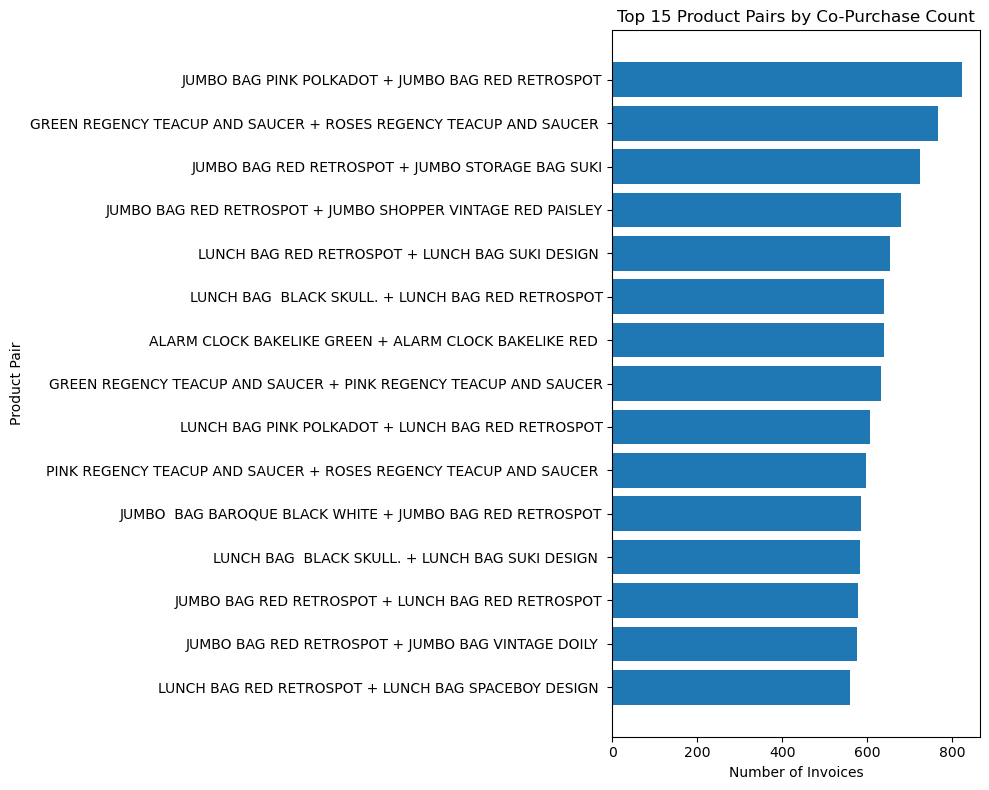

In [20]:
top_15_pairs = product_pairs.head(15).copy()

top_15_pairs["PairLabel"] = (
    top_15_pairs["ProductA"] + " + " + top_15_pairs["ProductB"]
)

plt.figure(figsize=(10, 8))
plt.barh(top_15_pairs["PairLabel"][::-1], top_15_pairs["PairCount"][::-1])
plt.title("Top 15 Product Pairs by Co-Purchase Count")
plt.xlabel("Number of Invoices")
plt.ylabel("Product Pair")
plt.tight_layout()
plt.show()

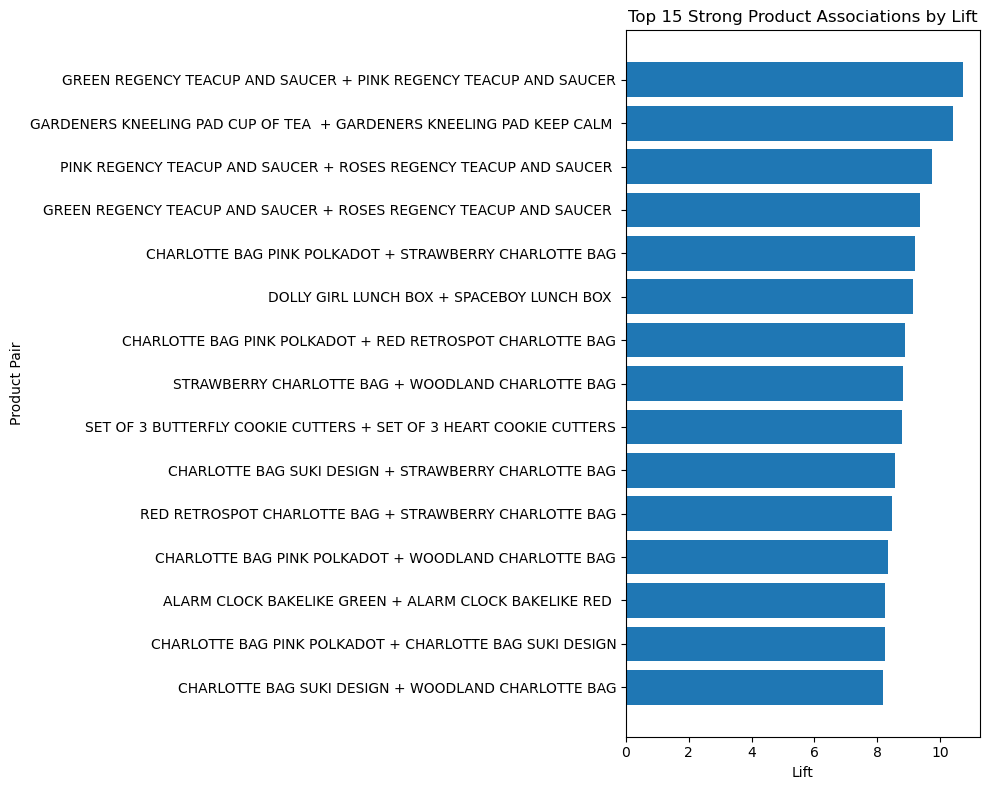

In [21]:
top_15_lift = strong_pairs.head(15).copy()

top_15_lift["PairLabel"] = (
    top_15_lift["ProductA"] + " + " + top_15_lift["ProductB"]
)

plt.figure(figsize=(10, 8))
plt.barh(top_15_lift["PairLabel"][::-1], top_15_lift["Lift"][::-1])
plt.title("Top 15 Strong Product Associations by Lift")
plt.xlabel("Lift")
plt.ylabel("Product Pair")
plt.tight_layout()
plt.show()

In [22]:
product_pairs.to_csv("../reports/product_pair_associations.csv", index=False)
strong_pairs.to_csv("../reports/strong_product_associations.csv", index=False)

print("Market basket analysis tables exported successfully.")

Market basket analysis tables exported successfully.


## Market Basket Analysis Summary

This notebook analyzed which products are frequently purchased together in the same invoice.

The analysis excluded non-product rows such as postage, fees, and manual adjustments, so the results focus only on real product combinations.

To keep the analysis efficient and understandable, the notebook focused on the top 100 most frequently appearing products.

Key findings:
- Many of the strongest product combinations come from the same product family.
- Jumbo bags are frequently purchased with other jumbo bag designs.
- Lunch bags are frequently purchased with other lunch bag designs.
- Regency teacups and saucers show strong co-purchase relationships.
- Alarm clocks and Christmas paper chain kits also appear as strong product pairs.

The strongest pair by co-purchase count was:
- JUMBO BAG PINK POLKADOT
- JUMBO BAG RED RETROSPOT

This pair appeared together in 825 invoices.

Business recommendation:
The business could use these product relationships to create bundles, cross-sell recommendations, or product placement strategies. For example, related bag designs or matching teacup sets could be promoted together.

Limitation:
This analysis uses a simple product-pair approach instead of a full association rule mining model. This makes it easier to explain and suitable for a beginner-friendly portfolio project, but future work could apply Apriori or FP-Growth for deeper association rule analysis.